Try the effect of rotating an FFT

2026.04.07

In [1]:

import numpy as np
from PIL import Image
import matplotlib

import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from scipy.fft import fft2, ifft2, fftshift, ifftshift

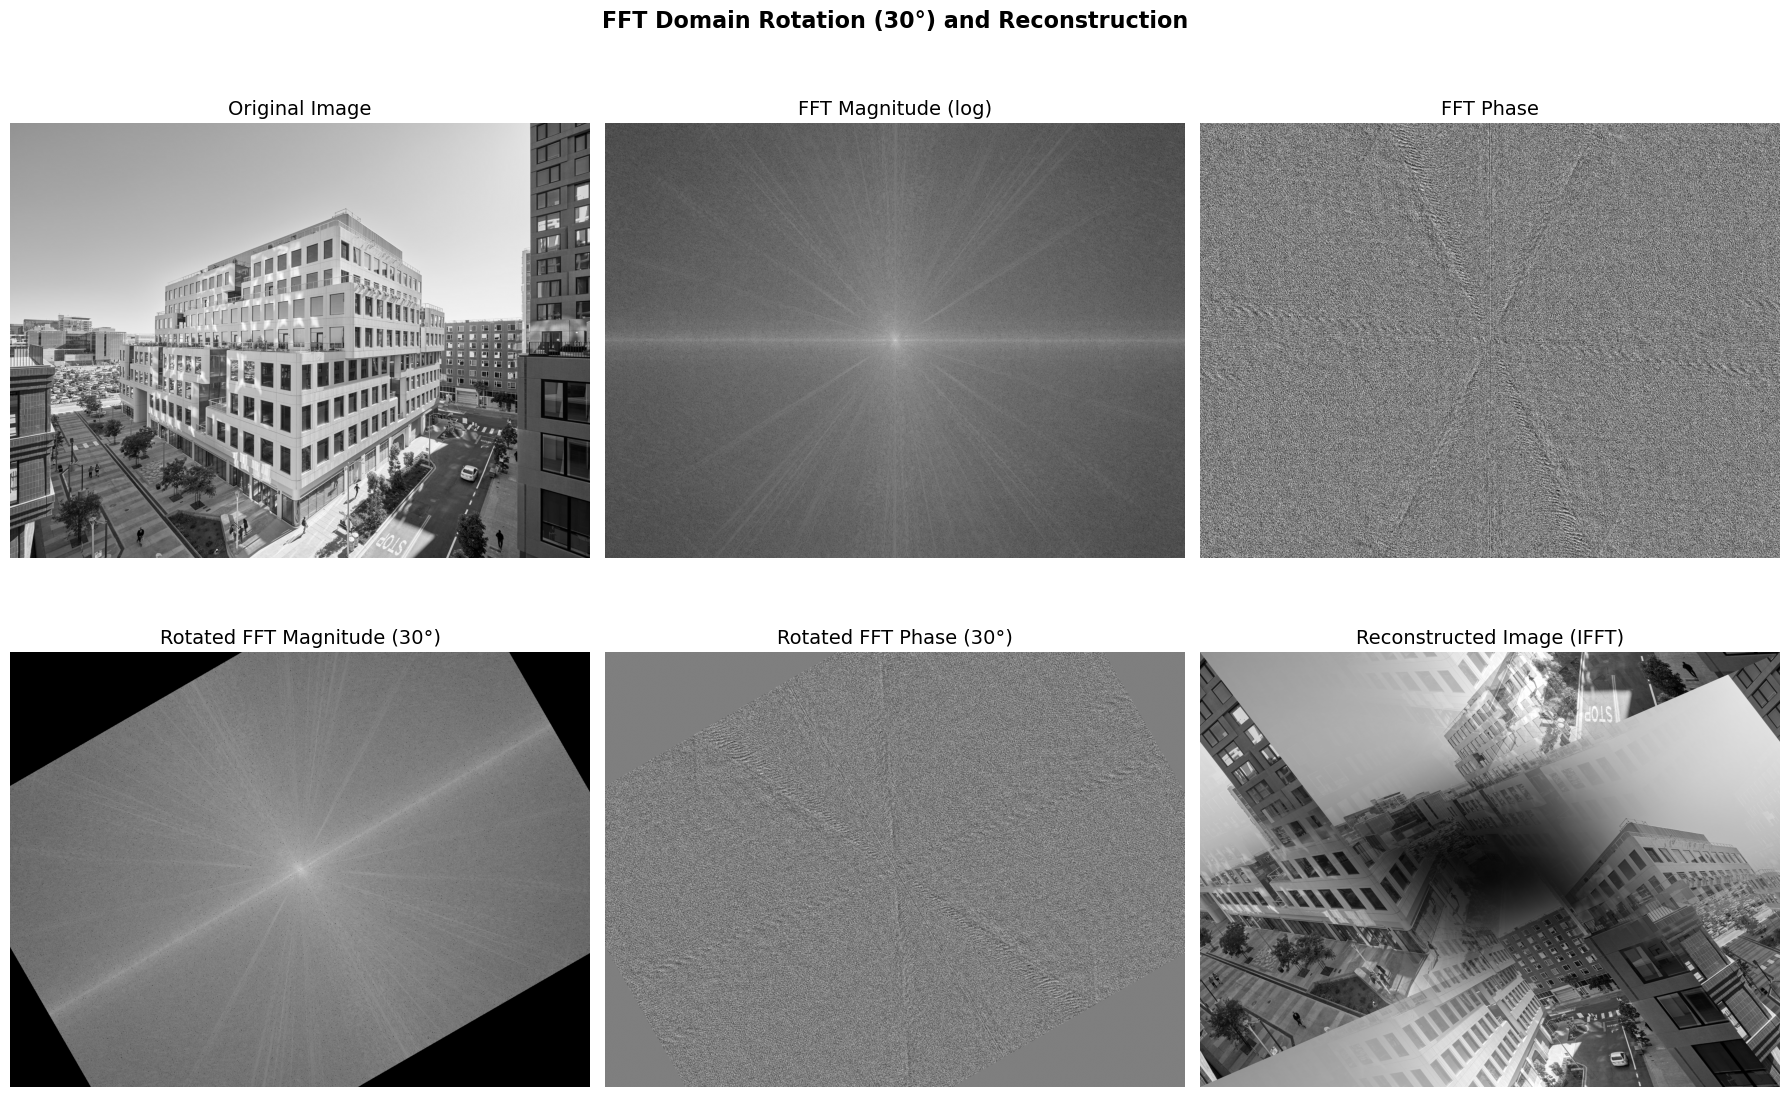

In [3]:
# Read the image and convert to grayscale
img = Image.open('/home/xz127/earth_project/Reconstruction/test3_1600_1200.jpg').convert('L')
img_array = np.array(img, dtype=np.float64)

# Compute 2D FFT and shift zero-frequency to center
f_img = fftshift(fft2(img_array, axes=(0, 1)), axes=(0, 1))

# Get magnitude and phase
magnitude = np.abs(f_img)
phase = np.angle(f_img)

# Rotate both magnitude and phase by 30 degrees
# Use reshape=True so no data is clipped, fill with 0
real_rotated = rotate(f_img.real, angle=30, reshape=False, order=3, mode='constant', cval=0)
imag_rotated = rotate(f_img.imag, angle=30, reshape=False, order=3, mode='constant', cval=0)

# Reconstruct the complex FFT from rotated magnitude and phase
f_rotated = real_rotated + 1j * imag_rotated
img_reconstructed = np.abs(ifft2(ifftshift(f_rotated)))

# Clip to valid range
img_reconstructed = np.clip(img_reconstructed, 0, 255).astype(np.uint8)

# Plot results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Original image
axes[0, 0].imshow(img_array, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=14)
axes[0, 0].axis('off')

# Original FFT magnitude (log scale)
axes[0, 1].imshow(np.log1p(magnitude), cmap='gray')
axes[0, 1].set_title('FFT Magnitude (log)', fontsize=14)
axes[0, 1].axis('off')

# Original FFT phase
axes[0, 2].imshow(phase, cmap='gray')
axes[0, 2].set_title('FFT Phase', fontsize=14)
axes[0, 2].axis('off')

# Rotated FFT magnitude (log scale)
axes[1, 0].imshow(np.log1p(mag_rotated), cmap='gray')
axes[1, 0].set_title('Rotated FFT Magnitude (30°)', fontsize=14)
axes[1, 0].axis('off')

# Rotated FFT phase
axes[1, 1].imshow(phase_rotated, cmap='gray')
axes[1, 1].set_title('Rotated FFT Phase (30°)', fontsize=14)
axes[1, 1].axis('off')

# Reconstructed image
axes[1, 2].imshow(img_reconstructed, cmap='gray')
axes[1, 2].set_title('Reconstructed Image (IFFT)', fontsize=14)
axes[1, 2].axis('off')

plt.suptitle('FFT Domain Rotation (30°) and Reconstruction', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
